# SARIMAX-XGBoost Residual Hybrid for CPI MoM Inflation

Clean residual-hybrid notebook for one-month-ahead CPI MoM inflation forecasting.

Core idea:

`Final forecast = SARIMAX forecast + XGBoost residual correction`

Why this model is suitable for the current CPI dataset:
- SARIMAX captures autoregressive, moving-average, seasonal, and linear exogenous effects.
- XGBoost learns nonlinear residual patterns that SARIMAX fails to explain.
- The feature engineering is based on lagged information to reduce look-ahead bias.
- The model is more suitable than large deep learning models for small monthly macroeconomic datasets.

In [1]:
import os, warnings, random
warnings.filterwarnings("ignore")

import numpy as np

if not hasattr(np, "matrix"):
    np.matrix = np.ndarray

import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from scipy.stats import jarque_bera
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except Exception:
    HAS_XGB = False
    print("xgboost is not installed. The notebook will use HistGradientBoostingRegressor as fallback.")

plt.style.use("seaborn-v0_8-darkgrid")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

DATA_DIR = os.path.join(os.getcwd(), "data", "processed")
OUTPUT_DIR = os.path.join(os.getcwd(), "outputs", "step9_sarimax_xgb_hybrid")
os.makedirs(OUTPUT_DIR, exist_ok=True)

MODEL_NAME = "SARIMAX-XGBoost Residual Hybrid"
MODEL_TAG = "sarimax_xgb_residual_hybrid"

In [2]:
target_var = "cpi_mom_inflation"
exog_vars = [
    "broad_money", "ppi_qoq", "wti", "gold",
    "policy_rate", "VNINDEX", "NIKKEI225", "USDVND"
]

df_raw = pd.read_csv(
    os.path.join(DATA_DIR, "cpi_forecast_selected_variables.csv"),
    index_col=0,
    parse_dates=True
)

df_all = df_raw[[target_var] + exog_vars].copy().dropna()

print(f"Raw data shape: {df_all.shape}")
print(f"Raw period: {df_all.index.min().date()} to {df_all.index.max().date()}")

Raw data shape: (360, 9)
Raw period: 1995-01-01 to 2024-12-01


In [3]:
def classify_stationarity(series):
    s = pd.Series(series).dropna()
    adf_p = adfuller(s, autolag="AIC", regression="c")[1]
    return "I(0)" if adf_p < 0.05 else "I(1)"

transformed, name_map, stationarity_map = {}, {}, {}

for col in df_all.columns:
    status = classify_stationarity(df_all[col])
    stationarity_map[col] = status

    if status == "I(0)":
        new_col = col
        transformed[new_col] = df_all[col]
    else:
        if col == "policy_rate" or (df_all[col] <= 0).any():
            new_col = f"diff_{col}"
            transformed[new_col] = df_all[col].diff()
        else:
            new_col = f"dlog_{col}"
            transformed[new_col] = np.log(df_all[col]).diff()

    name_map[col] = new_col

df = pd.DataFrame(transformed, index=df_all.index).dropna()
target_col = name_map[target_var]
exog_transformed_cols = [name_map[c] for c in exog_vars]

print("Stationarity and transformation")
for raw_col in df_all.columns:
    print(f"{raw_col}: {stationarity_map[raw_col]} -> {name_map[raw_col]}")

print(f"\nTransformed data shape: {df.shape}")
print(f"Target after transform: {target_col}")
print(f"Exogenous columns: {exog_transformed_cols}")

Stationarity and transformation
cpi_mom_inflation: I(0) -> cpi_mom_inflation
broad_money: I(1) -> dlog_broad_money
ppi_qoq: I(1) -> diff_ppi_qoq
wti: I(1) -> dlog_wti
gold: I(1) -> dlog_gold
policy_rate: I(1) -> diff_policy_rate
VNINDEX: I(1) -> dlog_VNINDEX
NIKKEI225: I(1) -> dlog_NIKKEI225
USDVND: I(1) -> dlog_USDVND

Transformed data shape: (359, 9)
Target after transform: cpi_mom_inflation
Exogenous columns: ['dlog_broad_money', 'diff_ppi_qoq', 'dlog_wti', 'dlog_gold', 'diff_policy_rate', 'dlog_VNINDEX', 'dlog_NIKKEI225', 'dlog_USDVND']


In [4]:
def build_model_frame(df, target_col, exog_cols):
    out = df.copy()

    # Calendar seasonality features, known in advance.
    month = out.index.month.values
    out["month_sin"] = np.sin(2 * np.pi * month / 12)
    out["month_cos"] = np.cos(2 * np.pi * month / 12)

    # Lagged inflation features.
    for lag in [1, 2, 3, 6, 12]:
        out[f"{target_col}_lag{lag}"] = out[target_col].shift(lag)

    # Rolling inflation features using past information only.
    out[f"{target_col}_roll_mean_3"] = out[target_col].rolling(3).mean().shift(1)
    out[f"{target_col}_roll_mean_6"] = out[target_col].rolling(6).mean().shift(1)
    out[f"{target_col}_roll_std_6"] = out[target_col].rolling(6).std().shift(1)
    out[f"{target_col}_roll_std_12"] = out[target_col].rolling(12).std().shift(1)

    # Regime feature based on past 12-month inflation volatility.
    vol_col = f"{target_col}_roll_std_12"
    threshold = out[vol_col].quantile(0.75)
    out["high_vol_regime"] = (out[vol_col] > threshold).astype(float)

    # Lagged exogenous variables. This avoids using same-month exog for one-month-ahead forecasting.
    for col in exog_cols:
        out[f"{col}_lag1"] = out[col].shift(1)
        out[f"{col}_lag2"] = out[col].shift(2)
        out[f"{col}_roll_mean_3"] = out[col].rolling(3).mean().shift(1)

    return out.dropna(), threshold

df_model, vol_threshold = build_model_frame(df, target_col, exog_transformed_cols)

sarimax_exog_cols = (
    [f"{c}_lag1" for c in exog_transformed_cols]
    + ["month_sin", "month_cos", f"{target_col}_roll_std_12", "high_vol_regime"]
)

xgb_feature_cols = [c for c in df_model.columns if c != target_col]

print("Feature engineering completed")
print(f"Model data shape: {df_model.shape}")
print(f"Model period: {df_model.index.min().date()} to {df_model.index.max().date()}")
print(f"Volatility threshold: {vol_threshold:.6f}")
print(f"SARIMAX exog columns: {len(sarimax_exog_cols)}")
print(sarimax_exog_cols)
print(f"XGBoost residual feature columns: {len(xgb_feature_cols)}")

Feature engineering completed
Model data shape: (347, 45)
Model period: 1996-02-01 to 2024-12-01
Volatility threshold: 0.955502
SARIMAX exog columns: 12
['dlog_broad_money_lag1', 'diff_ppi_qoq_lag1', 'dlog_wti_lag1', 'dlog_gold_lag1', 'diff_policy_rate_lag1', 'dlog_VNINDEX_lag1', 'dlog_NIKKEI225_lag1', 'dlog_USDVND_lag1', 'month_sin', 'month_cos', 'cpi_mom_inflation_roll_std_12', 'high_vol_regime']
XGBoost residual feature columns: 44


In [5]:
n = len(df_model)
train_end = int(0.70 * n)
val_end = int(0.80 * n)

train_df = df_model.iloc[:train_end].copy()
val_df = df_model.iloc[train_end:val_end].copy()
test_df = df_model.iloc[val_end:].copy()

print("Time-based split")
print(f"Train: {train_df.shape}, {train_df.index[0].date()} to {train_df.index[-1].date()}")
print(f"Val:   {val_df.shape}, {val_df.index[0].date()} to {val_df.index[-1].date()}")
print(f"Test:  {test_df.shape}, {test_df.index[0].date()} to {test_df.index[-1].date()}")

y_train = train_df[target_col]
y_val = val_df[target_col]
y_test = test_df[target_col]

X_sarimax_train = train_df[sarimax_exog_cols]
X_sarimax_val = val_df[sarimax_exog_cols]
X_sarimax_test = test_df[sarimax_exog_cols]

X_xgb_train = train_df[xgb_feature_cols]
X_xgb_val = val_df[xgb_feature_cols]
X_xgb_test = test_df[xgb_feature_cols]

Time-based split
Train: (242, 45), 1996-02-01 to 2016-03-01
Val:   (35, 45), 2016-04-01 to 2019-02-01
Test:  (70, 45), 2019-03-01 to 2024-12-01


In [6]:
# Default SARIMAX order is based on the best empirical result from previous experiments.
SARIMAX_ORDER = (1, 0, 2)
SARIMAX_SEASONAL_ORDER = (1, 0, 1, 12)

sarimax_model = SARIMAX(
    y_train,
    exog=X_sarimax_train,
    order=SARIMAX_ORDER,
    seasonal_order=SARIMAX_SEASONAL_ORDER,
    enforce_stationarity=False,
    enforce_invertibility=False,
    trend="c"
)

sarimax_res = sarimax_model.fit(disp=False, maxiter=500)
print(sarimax_res.summary())

c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                      SARIMAX Results                                       
Dep. Variable:                    cpi_mom_inflation   No. Observations:                  242
Model:             SARIMAX(1, 0, 2)x(1, 0, [1], 12)   Log Likelihood                -177.152
Date:                              Sat, 30 May 2026   AIC                            392.304
Time:                                      18:10:32   BIC                            457.378
Sample:                                  02-01-1996   HQIC                           418.562
                                       - 03-01-2016                                         
Covariance Type:                                opg                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
intercept                         0.0052      0.007      0.7

c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [7]:
# SARIMAX in-sample fitted values and out-of-sample forecasts.
sarimax_train_pred = sarimax_res.fittedvalues.reindex(train_df.index)

sarimax_val_pred = sarimax_res.get_forecast(
    steps=len(val_df),
    exog=X_sarimax_val
).predicted_mean
sarimax_val_pred.index = val_df.index

sarimax_test_pred = sarimax_res.get_forecast(
    steps=len(test_df),
    exog=X_sarimax_test
).predicted_mean
sarimax_test_pred.index = test_df.index

# Residual target for machine learning correction.
train_residual = y_train - sarimax_train_pred
train_residual = train_residual.dropna()

X_xgb_train_aligned = X_xgb_train.reindex(train_residual.index)

print("SARIMAX forecast and residual construction completed")
print(f"Train residual length: {len(train_residual)}")
print(f"Train residual mean: {train_residual.mean():.6f}")
print(f"Train residual std:  {train_residual.std():.6f}")

SARIMAX forecast and residual construction completed
Train residual length: 242
Train residual mean: 0.020292
Train residual std:  0.563079


In [8]:
# Scale XGB features for safety. XGBoost does not require scaling, but scaling helps fallback models.
x_scaler = StandardScaler()
X_xgb_train_scaled = x_scaler.fit_transform(X_xgb_train_aligned)
X_xgb_val_scaled = x_scaler.transform(X_xgb_val)
X_xgb_test_scaled = x_scaler.transform(X_xgb_test)

if HAS_XGB:
    residual_model = XGBRegressor(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.03,
        subsample=0.85,
        colsample_bytree=0.85,
        objective="reg:squarederror",
        random_state=SEED,
        reg_alpha=0.05,
        reg_lambda=1.0,
        min_child_weight=3
    )
else:
    residual_model = HistGradientBoostingRegressor(
        max_iter=300,
        learning_rate=0.03,
        max_leaf_nodes=15,
        l2_regularization=0.05,
        random_state=SEED
    )

residual_model.fit(X_xgb_train_scaled, train_residual.values)

val_residual_pred = pd.Series(
    residual_model.predict(X_xgb_val_scaled),
    index=val_df.index,
    name="xgb_residual_pred"
)

test_residual_pred = pd.Series(
    residual_model.predict(X_xgb_test_scaled),
    index=test_df.index,
    name="xgb_residual_pred"
)

print("Residual correction model fitted")
print(f"Residual model type: {type(residual_model).__name__}")

Residual correction model fitted
Residual model type: XGBRegressor


In [9]:
# Hybrid forecast.
hybrid_val_pred = sarimax_val_pred + val_residual_pred
hybrid_test_pred = sarimax_test_pred + test_residual_pred

# Also evaluate SARIMAX-only for comparison.
def compute_metrics(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {"Model": name, "RMSE": rmse, "MAE": mae, "R2": r2}

val_results = [
    compute_metrics(y_val, sarimax_val_pred, "SARIMAX only"),
    compute_metrics(y_val, hybrid_val_pred, "SARIMAX-XGB Hybrid")
]

test_results = [
    compute_metrics(y_test, sarimax_test_pred, "SARIMAX only"),
    compute_metrics(y_test, hybrid_test_pred, "SARIMAX-XGB Hybrid")
]

val_results_df = pd.DataFrame(val_results)
test_results_df = pd.DataFrame(test_results)

print("Validation results")
print(val_results_df)
print("\nTest results")
print(test_results_df)

Validation results
                Model      RMSE       MAE        R2
0        SARIMAX only  0.418743  0.354902 -0.050039
1  SARIMAX-XGB Hybrid  0.443234  0.375350 -0.176460

Test results
                Model      RMSE       MAE        R2
0        SARIMAX only  0.686070  0.501380 -0.227563
1  SARIMAX-XGB Hybrid  0.695269  0.515255 -0.260704


In [10]:
y_test_actual = y_test.copy()
y_pred = hybrid_test_pred.copy()

rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))
mae = mean_absolute_error(y_test_actual, y_pred)
r2 = r2_score(y_test_actual, y_pred)

# Random Walk benchmark.
y_rw = df_model[target_col].shift(1).reindex(test_df.index)
mask = ~np.isnan(y_rw)
rmse_rw = np.sqrt(mean_squared_error(y_test_actual[mask], y_rw[mask]))
mae_rw = mean_absolute_error(y_test_actual[mask], y_rw[mask])
vs_rw = rmse / rmse_rw if rmse_rw > 0 else np.nan

# Mean baseline.
y_mean = np.repeat(np.mean(y_test_actual), len(y_test_actual))
rmse_mean = np.sqrt(mean_squared_error(y_test_actual, y_mean))
mae_mean = mean_absolute_error(y_test_actual, y_mean)
vs_mean = rmse / rmse_mean if rmse_mean > 0 else np.nan

print("\n" + "="*80)
print("SARIMAX-XGBOOST RESIDUAL HYBRID TEST RESULTS")
print("="*80)
print(f"R²:                 {r2:.4f}")
print(f"RMSE:               {rmse:.6f}")
print(f"MAE:                {mae:.6f}")
print(f"Random Walk RMSE:   {rmse_rw:.6f}")
print(f"Random Walk MAE:    {mae_rw:.6f}")
print(f"Model / RW RMSE:    {vs_rw:.4f}")
print(f"Mean Baseline RMSE: {rmse_mean:.6f}")
print(f"Mean Baseline MAE:  {mae_mean:.6f}")
print(f"Model / Mean RMSE:  {vs_mean:.4f}")
print("="*80)

if vs_rw < 1:
    print("Interpretation: hybrid model beats Random Walk by RMSE.")
else:
    print("Interpretation: hybrid model does not beat Random Walk by RMSE.")

if vs_mean < 1:
    print("Interpretation: hybrid model beats Mean baseline, so R² should be positive.")
else:
    print("Interpretation: hybrid model does not beat Mean baseline, so R² can be negative.")


SARIMAX-XGBOOST RESIDUAL HYBRID TEST RESULTS
R²:                 -0.2607
RMSE:               0.695269
MAE:                0.515255
Random Walk RMSE:   0.897799
Random Walk MAE:    0.628645
Model / RW RMSE:    0.7744
Mean Baseline RMSE: 0.619222
Mean Baseline MAE:  0.462731
Model / Mean RMSE:  1.1228
Interpretation: hybrid model beats Random Walk by RMSE.
Interpretation: hybrid model does not beat Mean baseline, so R² can be negative.


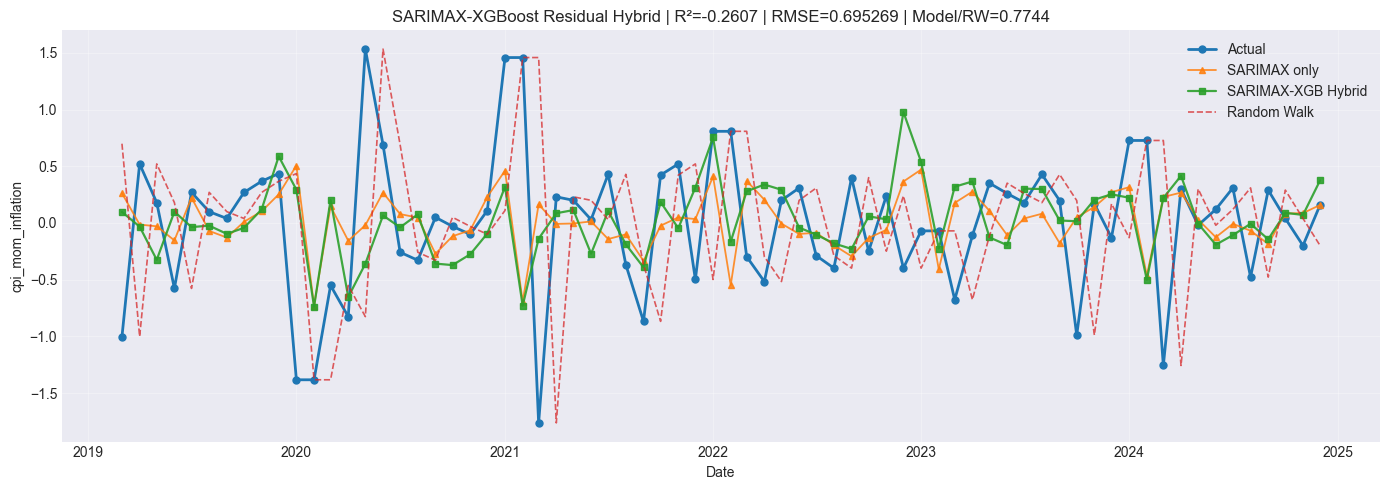

In [11]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(test_df.index, y_test_actual, "o-", label="Actual", markersize=5, linewidth=2)
ax.plot(test_df.index, sarimax_test_pred, "^-", label="SARIMAX only", markersize=4, linewidth=1.3, alpha=0.85)
ax.plot(test_df.index, y_pred, "s-", label="SARIMAX-XGB Hybrid", markersize=4, linewidth=1.6, alpha=0.90)
ax.plot(test_df.index[mask], y_rw[mask], "--", label="Random Walk", linewidth=1.2, alpha=0.75)

ax.set_title(f"{MODEL_NAME} | R²={r2:.4f} | RMSE={rmse:.6f} | Model/RW={vs_rw:.4f}")
ax.set_xlabel("Date")
ax.set_ylabel(target_col)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f"{MODEL_TAG}_forecast.png"), dpi=150)
plt.show()

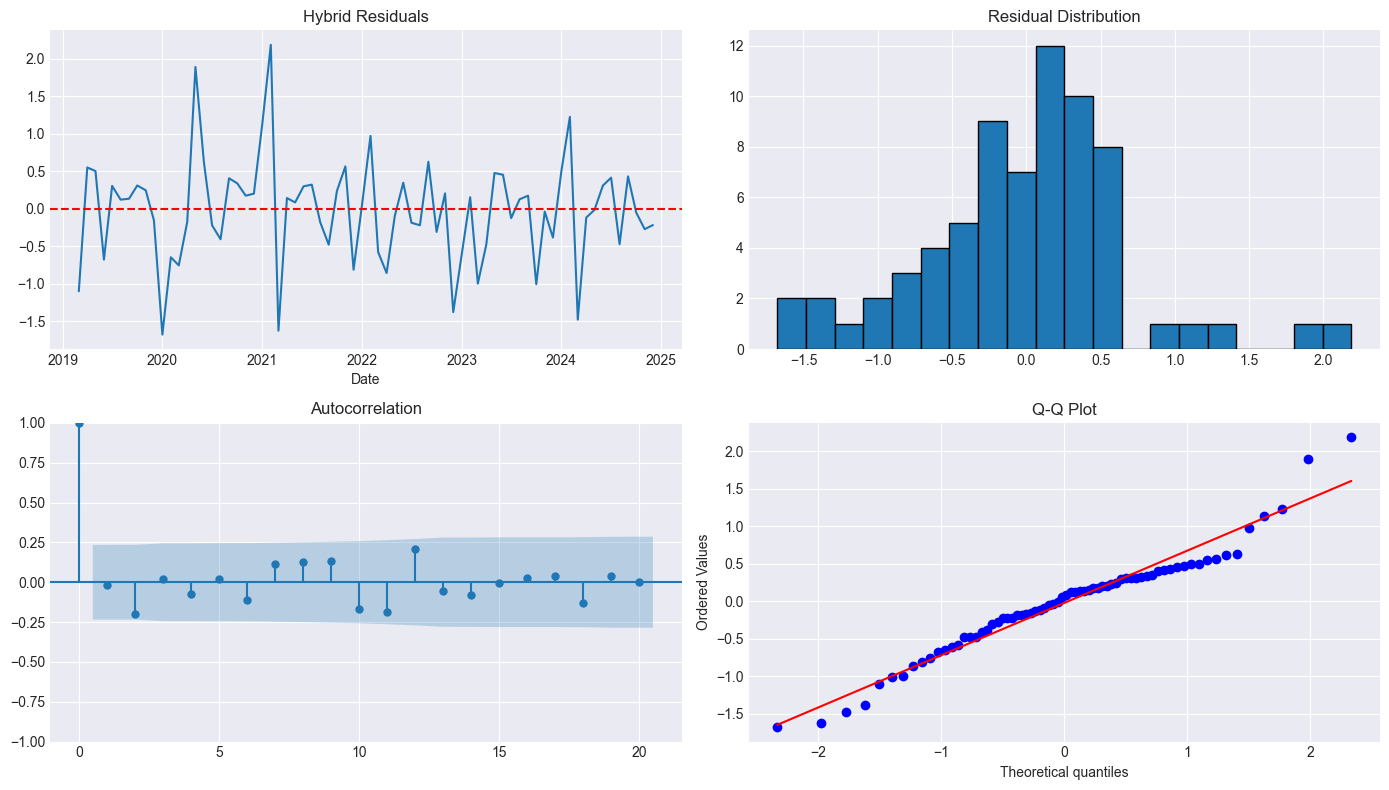

Residual diagnostics
Residual mean: -0.020418
Residual std:  0.694970
Jarque-Bera p-value: 0.064223


In [12]:
residuals = y_test_actual - y_pred
max_lags = min(20, len(residuals) - 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(test_df.index, residuals)
axes[0, 0].axhline(0, color="red", linestyle="--")
axes[0, 0].set_title("Hybrid Residuals")
axes[0, 0].set_xlabel("Date")

axes[0, 1].hist(residuals, bins=20, edgecolor="black")
axes[0, 1].set_title("Residual Distribution")

plot_acf(residuals, lags=max_lags, ax=axes[1, 0])
stats.probplot(residuals, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("Q-Q Plot")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f"{MODEL_TAG}_residuals.png"), dpi=150)
plt.show()

jb_stat, jb_p = jarque_bera(residuals)

print("Residual diagnostics")
print(f"Residual mean: {np.mean(residuals):.6f}")
print(f"Residual std:  {np.std(residuals):.6f}")
print(f"Jarque-Bera p-value: {jb_p:.6f}")

Top 20 XGBoost residual correction features
                          feature  importance
16  cpi_mom_inflation_roll_mean_6    0.048752
18  cpi_mom_inflation_roll_std_12    0.043394
2                        dlog_wti    0.038571
33          diff_policy_rate_lag2    0.038140
11         cpi_mom_inflation_lag2    0.037446
22   dlog_broad_money_roll_mean_3    0.036631
42               dlog_USDVND_lag2    0.036582
14        cpi_mom_inflation_lag12    0.035143
4                diff_policy_rate    0.033430
17   cpi_mom_inflation_roll_std_6    0.033430
15  cpi_mom_inflation_roll_mean_3    0.033309
5                    dlog_VNINDEX    0.029572
43        dlog_USDVND_roll_mean_3    0.029467
10         cpi_mom_inflation_lag1    0.028845
27                  dlog_wti_lag2    0.028103
39            dlog_NIKKEI225_lag2    0.025851
31          dlog_gold_roll_mean_3    0.025522
6                  dlog_NIKKEI225    0.024679
7                     dlog_USDVND    0.023588
26                  dlog_wti_lag1   

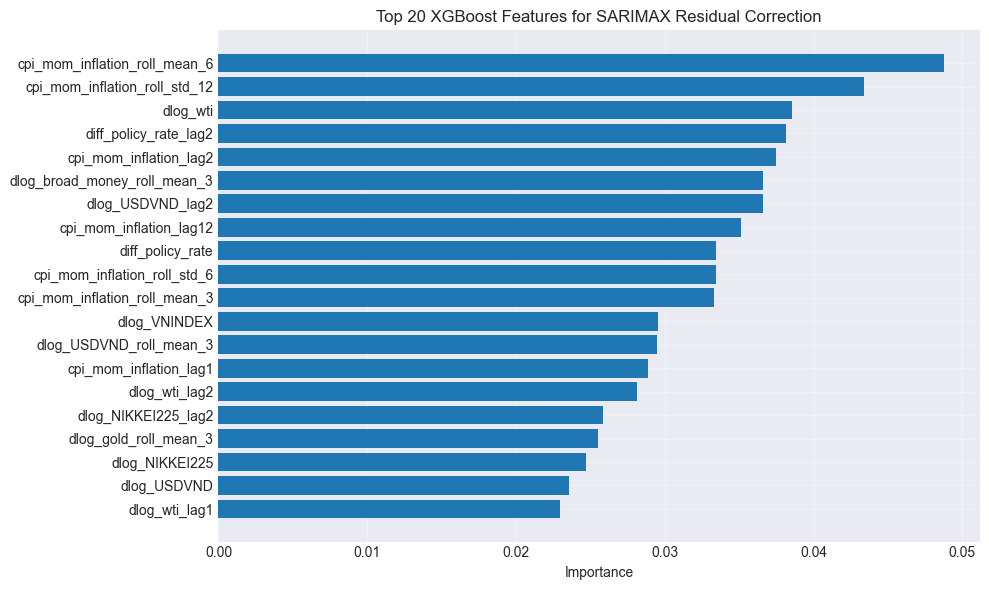

In [13]:
# Feature importance for residual correction model.
if HAS_XGB and hasattr(residual_model, "feature_importances_"):
    importance = residual_model.feature_importances_
    feature_importance_df = pd.DataFrame({
        "feature": X_xgb_train_aligned.columns,
        "importance": importance
    }).sort_values("importance", ascending=False)

    print("Top 20 XGBoost residual correction features")
    print(feature_importance_df.head(20))

    fig, ax = plt.subplots(figsize=(10, 6))
    top_features = feature_importance_df.head(20).iloc[::-1]
    ax.barh(top_features["feature"], top_features["importance"])
    ax.set_title("Top 20 XGBoost Features for SARIMAX Residual Correction")
    ax.set_xlabel("Importance")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f"{MODEL_TAG}_feature_importance.png"), dpi=150)
    plt.show()
else:
    print("Feature importance is not available for the fallback residual model.")

In [14]:
comparison_df = pd.DataFrame([
    {
        "Model": "Random Walk",
        "RMSE": rmse_rw,
        "MAE": mae_rw,
        "R2": np.nan,
        "Model_vs_RW": 1.0,
        "Model_vs_Mean": rmse_rw / rmse_mean if rmse_mean > 0 else np.nan
    },
    {
        "Model": "Mean Baseline",
        "RMSE": rmse_mean,
        "MAE": mae_mean,
        "R2": 0.0,
        "Model_vs_RW": rmse_mean / rmse_rw if rmse_rw > 0 else np.nan,
        "Model_vs_Mean": 1.0
    },
    {
        "Model": "SARIMAX only",
        "RMSE": test_results_df.loc[test_results_df["Model"] == "SARIMAX only", "RMSE"].values[0],
        "MAE": test_results_df.loc[test_results_df["Model"] == "SARIMAX only", "MAE"].values[0],
        "R2": test_results_df.loc[test_results_df["Model"] == "SARIMAX only", "R2"].values[0],
        "Model_vs_RW": test_results_df.loc[test_results_df["Model"] == "SARIMAX only", "RMSE"].values[0] / rmse_rw,
        "Model_vs_Mean": test_results_df.loc[test_results_df["Model"] == "SARIMAX only", "RMSE"].values[0] / rmse_mean
    },
    {
        "Model": "SARIMAX-XGB Hybrid",
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "Model_vs_RW": vs_rw,
        "Model_vs_Mean": vs_mean
    }
])

print("Final comparison")
print(comparison_df.sort_values("RMSE"))

comparison_df.to_csv(os.path.join(OUTPUT_DIR, f"{MODEL_TAG}_comparison.csv"), index=False)

Final comparison
                Model      RMSE       MAE        R2  Model_vs_RW  \
1       Mean Baseline  0.619222  0.462731  0.000000     0.689712   
2        SARIMAX only  0.686070  0.501380 -0.227563     0.764169   
3  SARIMAX-XGB Hybrid  0.695269  0.515255 -0.260704     0.774416   
0         Random Walk  0.897799  0.628645       NaN     1.000000   

   Model_vs_Mean  
1       1.000000  
2       1.107955  
3       1.122811  
0       1.449881  


In [15]:
print("\n" + "="*80)
print("SARIMAX-XGBOOST RESIDUAL HYBRID SUMMARY")
print("="*80)
print(f"Model: {MODEL_NAME}")
print(f"Target: {target_col}")
print(f"SARIMAX order: {SARIMAX_ORDER}")
print(f"SARIMAX seasonal order: {SARIMAX_SEASONAL_ORDER}")
print(f"SARIMAX exogenous variables: {len(sarimax_exog_cols)}")
print(f"Residual correction model: {type(residual_model).__name__}")
print(f"Residual correction features: {len(xgb_feature_cols)}")
print(f"Train samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"Test samples: {len(test_df)}")
print(f"R²: {r2:.4f}")
print(f"RMSE: {rmse:.6f}")
print(f"MAE: {mae:.6f}")
print(f"Random Walk RMSE: {rmse_rw:.6f}")
print(f"Model / Random Walk RMSE: {vs_rw:.4f}")
print(f"Model / Mean RMSE: {vs_mean:.4f}")
print("="*80)


SARIMAX-XGBOOST RESIDUAL HYBRID SUMMARY
Model: SARIMAX-XGBoost Residual Hybrid
Target: cpi_mom_inflation
SARIMAX order: (1, 0, 2)
SARIMAX seasonal order: (1, 0, 1, 12)
SARIMAX exogenous variables: 12
Residual correction model: XGBRegressor
Residual correction features: 44
Train samples: 242
Validation samples: 35
Test samples: 70
R²: -0.2607
RMSE: 0.695269
MAE: 0.515255
Random Walk RMSE: 0.897799
Model / Random Walk RMSE: 0.7744
Model / Mean RMSE: 1.1228
